# Práctica 4

Descripción: Cálculo integral. Integración numérica.

Bibliografía: https://pythonnumericalmethods.berkeley.edu/notebooks/Index.html
              J. M. Stewart, Python for scientists. Cambridge University Press.

## Sumas de Riemann

Podemos utilizar las sumas de Riemann para realizar la aproximación de una integral definida. Para ello realizaremos una partición del intervalo y tomaremos un valor de la función en cada subintervalo que hemos considerado, dependiendo de dicho valor podemos obtener valores por exceso o por defecto. Vamos a cargar los módulos que vamos a utilizar en esta parte.

In [1]:
import numpy as np
import sympy as sy

Vamos a calcular una suma asociada a la integral $\int_0^{\pi} \sin(x)\,dx$. 

In [2]:
a = 0
b = np.pi
numero_puntos_particion = 20
numero_subintervalos = numero_puntos_particion - 1
h = (b - a)/numero_subintervalos
x = np.linspace(a, b, numero_puntos_particion)
f = np.sin(x)

suma_riemann1 = h * sum(f[: numero_subintervalos])
suma_riemann1

np.float64(1.9954413183201947)

Observa que el valor obtenido es próximo al valor de la integral (2).

## Integración con SymPy

SymPy dispone de métodos que nos permiten calcular las integrales tal 
y como lo haríamos sin utilizar técnicas de tipo numérico.

Para ello necesitamos definir la variable. También definiremos la función
$f(x)$ para poder trabajar con ella de forma simbólica.

In [3]:
x = sy.symbols('x')
f = sy.symbols('f', cls = sy.Function) #Cls = clase única, 

El comando para integrar es sy.integrate(f(x), (x, a, b)). Veamos unos ejemplos.

In [4]:
sy.integrate(sy.sin(x), x)

-cos(x)

In [5]:
sy.integrate(sy.sin(x),(x, 0, sy.pi))

2

Realiza las siguientes integrales utilizando sy.integrate.

a) $\int_{-1}^1 (x^3+1)\,dx$

b) $\int_0^3\sqrt{x+1}\,dx$

c) $\int_{-1}^1 \cos(x+\pi)\,dx$

In [6]:
##Escribe aquí el código
sy.integrate(x**3 + 1, (x, -1, 1))

2

In [7]:
sy.integrate(sy.sqrt(x + 1), (x, 0, 3))

14/3

In [8]:
sy.integrate(sy.cos(x + sy.pi), (x, -1, 1))

-2*sin(1)

¿Qué sucede con la siguiente integral? 
$$erf(x)=\frac{2}{\sqrt{\pi}}\int_0^x e^{-t^2}\,dt \,$$

Ejecuta los siguientes comandos. ¿Qué ocurre?

In [9]:
t = sy.symbols('t')
2/sy.sqrt(sy.pi)*sy.integrate(sy.exp(-t**2), (t, 0, x))

erf(x)

En estos casos en los que no tenemos una primitva de la función podemos calcular
de forma aproximada la integral.

## Integración numérica

Disponemos de diferentes métodos numéricos que nos permiten el cálculo de 
integrales utilizando el ordenador. En este caso utilizaremos la regla del 
trapecio y el método de Simpson.

### La regla del trapecio

Como su propio nombre indica se obtiene sumando las áreas de los trapecios
que obtenemos cuando una vez fijada una partición $\mathcal{P}=\{a=x_0, x_1,
\ldots, x_n=b\}$, unimos los puntos $\{f(a), f(x_1), \ldots, f(x_n)=f(b)\}$. 
Ahora el área del trapecio formado por los puntos $\{f(x_i), x_i, x_{i+1}, 
f(x_{i+1})\}$ viene dada por
$$\frac{(f(x_i)+f(x_{i+1}))}{2}\cdot (x_{i+1} - x_i),$$
para $i=0,\ldots, n-1$. Considerando la partición en la que el paso es 
constante, es decir, $x_i= x_0+ i \cdot h$ para $i=1,\ldots, n$.
De esta forma la aproximación del valor de la integral
utilizando la regla del trapecio viene dada por:

$$\int_a^b f(x)\,dx\approx \frac{h}{2}\left(f(a)+2 \sum_{i=1}^{n-1} f(x_i)+f(b)
\right),$$
siendo $h=\frac{b-a}{n}$.

Veamos un ejemplo de aplicación de la regla del trapecio. Calcularemos
utilizando dicha fórmula un valor aproximado de la integral $\int_0^1 x^2\,dx$.

In [10]:
a = 0
b = 1
numero_puntos = 10
numero_subintervalos= numero_puntos - 1
h = (b - a)/numero_subintervalos
x = np.linspace(a, b, numero_puntos)
f = x**2
I_trapecio = h/2*(f[0] + 2 * sum(f[1:numero_subintervalos])+ 
f[numero_subintervalos])
I_trapecio

np.float64(0.33539094650205753)

Modifica el número de puntos de la expresión anterior y observa cómo cambia el 
valor, aproximándose al valor real de la integral.

Podemos definir una función que aplique la regla del trapecio al intervalo y la
función seleccionadas.

In [50]:
def regla_trapecio(f, a, b, n):
    '''Estimación del valor de la integral en el intervalo [a,b] utilizando
    una partición con n puntos'''
    numero_puntos = int(n)
    numero_subintervalos = numero_puntos - 1
    h = (b - a)/numero_subintervalos
    x = np.linspace(a, b, numero_puntos)
    y = f(x)
    print(f'''El valor de la integral es {h/2*(y[0] + 
    2 * sum(y[1:numero_subintervalos])+ 
    y[numero_subintervalos])}''')

In [12]:
def parabola(x):
    return(x**2)
regla_trapecio(parabola, 0, 1, 10)

El valor de la integral es 0.33539094650205753


Ejercicio propuesto. Utiliza la regla del trapecio para dar una aproximación de 
$erf(1)$.

In [13]:
#### Introduce aquí el código
def expinencial(x):
    return(np.exp(-x**2))

regla_trapecio(expinencial, 0, 1, 100)


El valor de la integral es 0.7468178769764187


Observación: El valor "real" viene dado por:

In [14]:
sy.N(sy.erf(1))*np.sqrt(np.pi)/2

0.746824132812427

Ejercicio propuesto. Utilizando la regla del trapecio calcula una estimación, 
$E_T$, de la integral $\int_0^2 x^3+x \,dx$ utilizando una partición de
6 puntos. Calcula el valor de la integral real $E$ y utiliza la fórmula
$$ \frac{|E_T|}{E}\cdot 100,$$
para expresar el valor obtenido utilizando la regla del trapecio como un 
porcentaje del valor verdadero de la integral.

Veamos a continuación la regla o método de Simpson.

In [15]:
def funcion1(x):
    return(x**3+x)

regla_trapecio(funcion1,0,2,6)

El valor de la integral es 6.160000000000001


In [24]:
x = sy.symbols("x")
sy.integrate(x**3 + x, (x,0,2))

6

In [26]:
error = 6.160000000000001/6 * 100
print(error)
"""Por exceso ya que es ma
yor de 100"""

102.66666666666669


### La regla de Simpson

La regla de Simpson sigue una idea similar al anterior método, salvo que en este
caso se utilizan parábolas en lugar de trapecios. La fórmula viene dada por

$$\int_a ^b f(x)\,dx\approx \frac{h}{3}\left(f(a)+4\cdot \sum_{ i\text{ impar}
\, 
i\neq 0,n}
f(x_{i})+2\cdot \sum_{i \text{ par}\,i\neq 0,n} f(x_i) + f(b)\right),$$
siendo $h=\frac{b-a}{n}$.
Importante: El número de subintervalos debe ser par.

Ejercicio propuesto. Utilizando la regla de Simpson calcula una estimación, 
$E_S$, de la integral $\int_0^2 x^3+x \,dx$ utilizando una partición de
6 puntos. Calcula el valor de la integral real $E$ y utiliza la fórmula
$$ \frac{|E_S|}{E}\cdot 100,$$
para expresar el valor obtenido utilizando la regla del trapecio como un 
porcentaje del valor verdadero de la integral.

In [58]:

i = sy.symbols('i')

def simpsonf(a, b, numero_puntos):
    int(numero_puntos)
    tope2 = int((numero_puntos - 1)/2)
    numero_subintervalos = numero_puntos - 1
    h = (b - a)/numero_subintervalos
    x = np.linspace(a, b, numero_puntos)
    f = x**3 + x

    E_S = h/3 * (f[0] + 4*sum([f[2*i + 1] for i in range(0, tope2)]) 
    + 2*sum([f[2* i] for i in range(1, tope2 )]) + f[numero_puntos-1])
    print(E_S)


simpsonf(0, 2, 7)

5.999999999999998


In [67]:
E_S =(f[0]+4*(f[1]+f[3]+f[5])+2*(f[2]+f[4])+f[6])*2/18

In [68]:
E_S/6 * 100

np.float64(99.99999999999997)

In [19]:
x = sy.symbols('x')
sy.integrate(x**3 + x, (x, 0, 2))

6

In [59]:
E_S/6*100

np.float64(99.99999999999997)

Ejercicio propuesto. Calcule erf(1) utilizando la regla de Simpson con 10 
puntos. Modifica el número de puntos para mejorar el resultado.

In [21]:
a = 0
b = 1
i = sy.symbols('i')
numero_puntos = 11
int(numero_puntos)
tope2 = int((numero_puntos - 1)/2)
numero_subintervalos = numero_puntos - 1
h = (b - a)/numero_subintervalos
x = np.linspace(a, b, numero_puntos)
f = np.exp(-x**2)
E_S = h/3 * (f[0] + 4*sum([f[2*i + 1] for i in range(0, tope2)]) 
+ 2*sum([f[2* i] for i in range(1,tope2 )]) + f[numero_puntos-1])
E_S



np.float64(0.7468249482544436)

In [22]:
sy.N(sy.erf(1))*np.sqrt(np.pi)/2

0.746824132812427

## Módulos de Scipy: trapezoid y simpson

Otra forma es utilizar directamente de scipy los módulos trapezoid y simpson.

In [2]:
from scipy.integrate import trapezoid
from scipy.integrate import simpson

In [7]:
import numpy as np
a = 0
b = 2
numero_puntos = 7
int(numero_puntos)
tope1 = int(numero_puntos/2 - 1)
tope2 = int(numero_puntos/2)
numero_subintervalos = numero_puntos - 1
h = (b - a)/numero_subintervalos
x = np.linspace(a, b, numero_puntos)
f = x**3 + x
I_trap2 = trapezoid(f, x)
I_trap2

np.float64(6.111111111111111)

In [42]:

I_sim2 = simpson(f, x)  # dx is the spacing between points
print(I_sim2)

TypeError: simpson() takes 1 positional argument but 2 were given

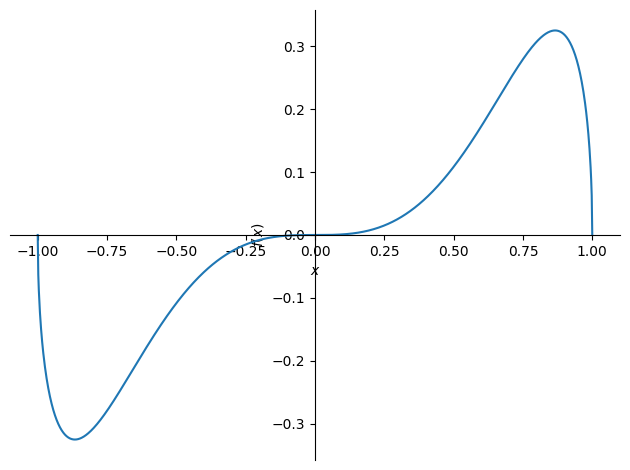

In [ ]:
x = sy.symbols("x")
sy.plot(x**3 * sy.sqrt(1 - x**2), (x, -1, 1))


#Es una fución impar por lo que f(-x) == -f(x) ----> Integral definida es 0

In [53]:
def funcion2(x):
    return x**3 * np.sqrt(1 - x**2)

regla_trapecio(funcion2, -1, 1, 11)

El valor de la integral es 6.66133814775094e-17


In [69]:
n = sy.symbols("n")
sy.summation(1/2**n, (n, 1, sy.oo))

1